Scanning runs_compare ...
Found 6 configuration(s):
  ver1_P2ETG_N3_K3_a2.0: 5 seed(s)
  ver1_PrefLID_N3_K3_b20000: 5 seed(s)
  ver1_PrefLID_N5_K5_b20000: 10 seed(s)
  ver25_PrefLID_N8_K8_b20000: 20 seed(s)
  ver3_P2ETG_N5_K5_a2.0: 5 seed(s)
  ver6_P2ETG_N8_K8_a2.0: 5 seed(s)
Found 6 configurations:
  ver1_P2ETG_N3_K3_a2.0: 5 seeds
  ver1_PrefLID_N3_K3_b20000: 5 seeds
  ver1_PrefLID_N5_K5_b20000: 10 seeds
  ver25_PrefLID_N8_K8_b20000: 20 seeds
  ver3_P2ETG_N5_K5_a2.0: 5 seeds
  ver6_P2ETG_N8_K8_a2.0: 5 seeds
Saved: plots/individual_regrets.png


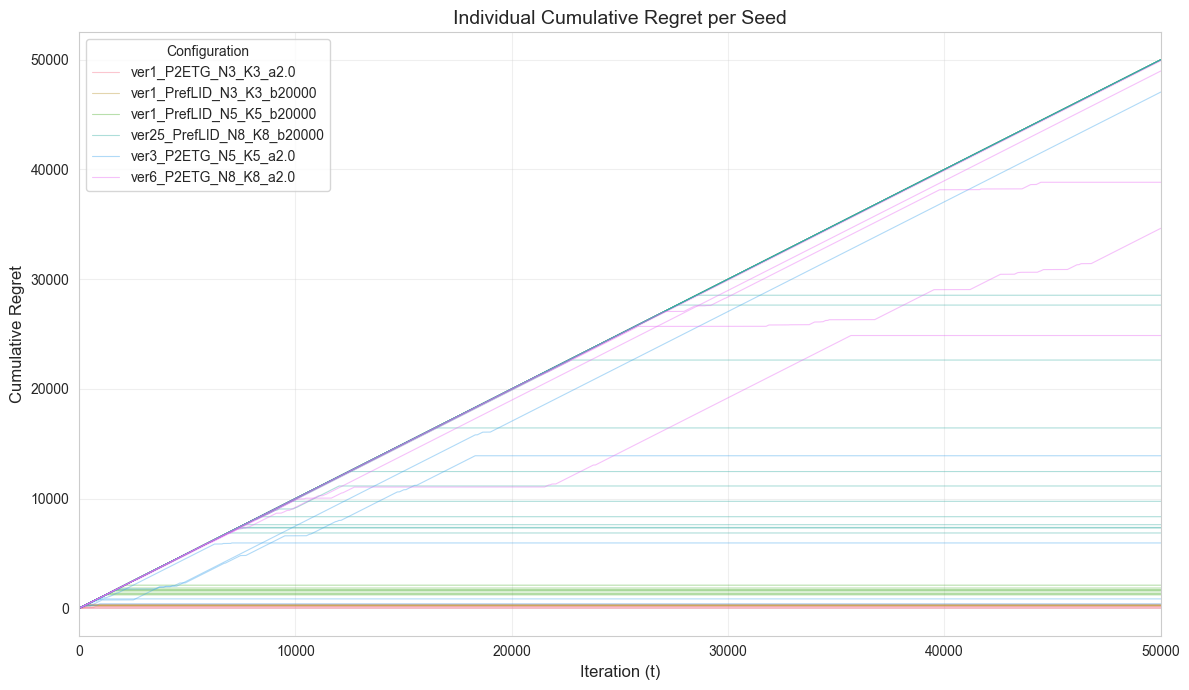

Saved: plots/mean_regret_std.png


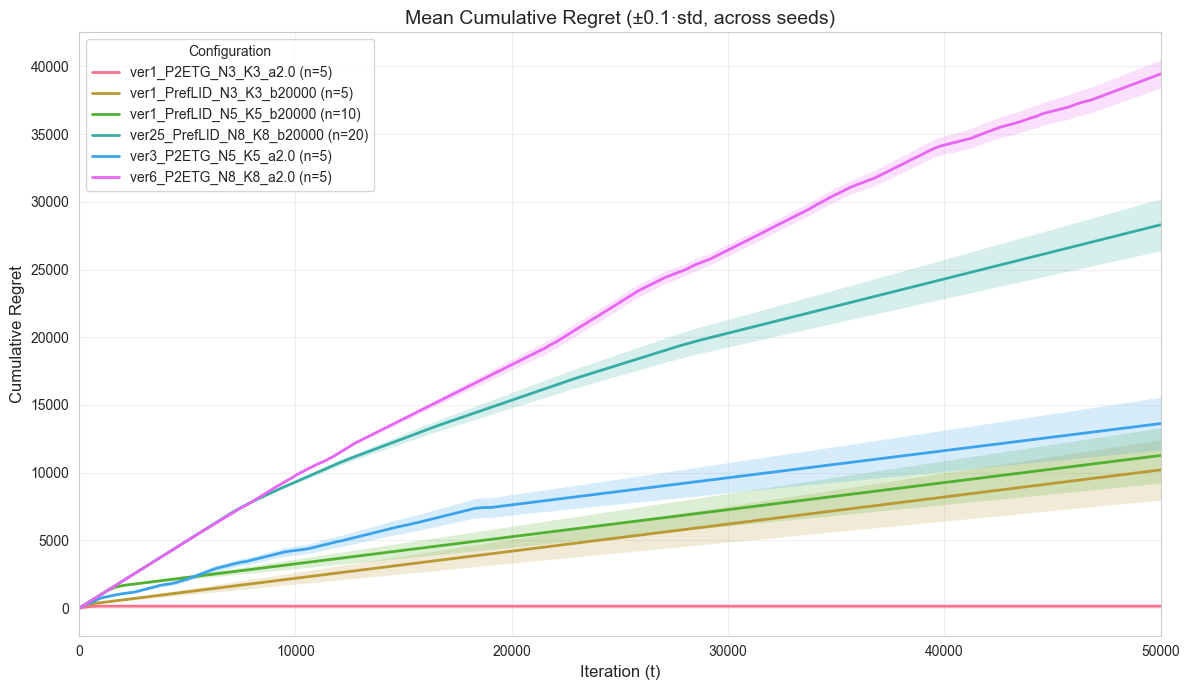

Saved: plots/summary_stats.png


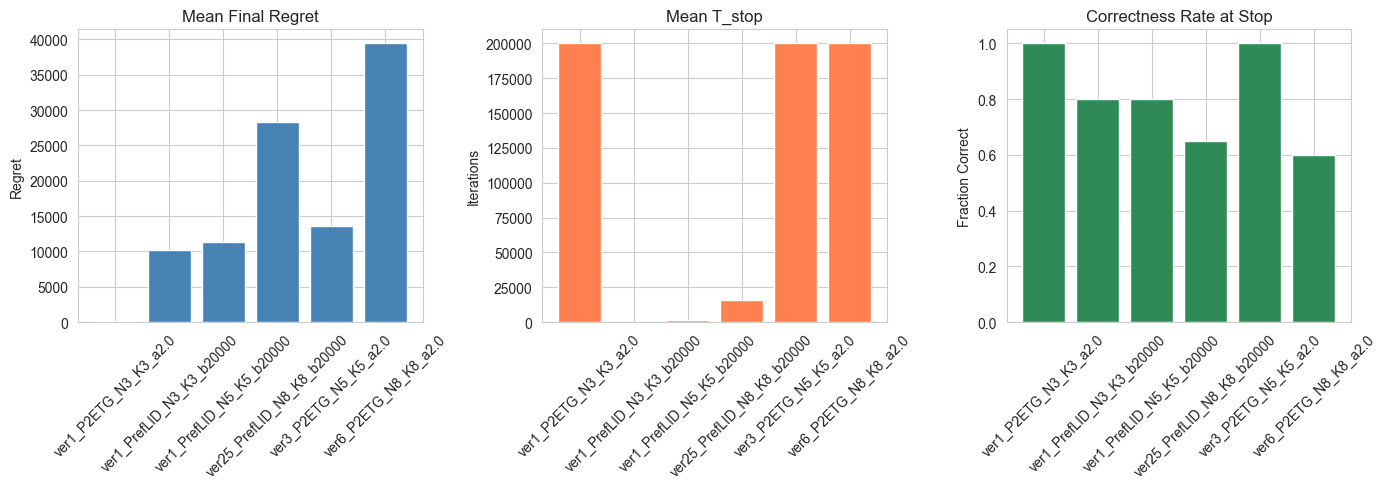

(<Figure size 1400x500 with 3 Axes>,
 array([<Axes: title={'center': 'Mean Final Regret'}, ylabel='Regret'>,
        <Axes: title={'center': 'Mean T_stop'}, ylabel='Iterations'>,
        <Axes: title={'center': 'Correctness Rate at Stop'}, ylabel='Fraction Correct'>],
       dtype=object))

In [1]:
# regret_plotting.py

# import os
# import json
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# from pathlib import Path
# import re

from plotting import *

# ---- CONFIGURE THIS ----
BASE_DIR = "runs_compare"   # <-- change me
MAX_ITERATIONS = 50000
OUTPUT_DIR = "plots"                # where to save figures
# ------------------------

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Load all data
print(f"Scanning {BASE_DIR} ...")
all_data = load_all_configs(BASE_DIR, max_iterations=MAX_ITERATIONS)

if not all_data:
    raise SystemExit("No configuration folders found. Check BASE_DIR.")

print(f"Found {len(all_data)} configurations:")
for cfg, seeds in all_data.items():
    print(f"  {cfg}: {len(seeds)} seeds")

# 1) Individual regret curves
plot_individual_regrets(
    all_data,
    max_iterations=MAX_ITERATIONS,
    save_path=os.path.join(OUTPUT_DIR, "individual_regrets.png"),
)

# 2) Mean ± std regret curves
plot_mean_regret_with_std(
    all_data,
    max_iterations=MAX_ITERATIONS,
    save_path=os.path.join(OUTPUT_DIR, "mean_regret_std.png"),
    std_multiplier=0.1,
    show_individual=False,   # <-- no individual seed lines
)

# 3) Summary stats
plot_summary_stats(
    all_data,
    save_path=os.path.join(OUTPUT_DIR, "summary_stats.png"),
)

Saved: plots/mean_regret_std.png


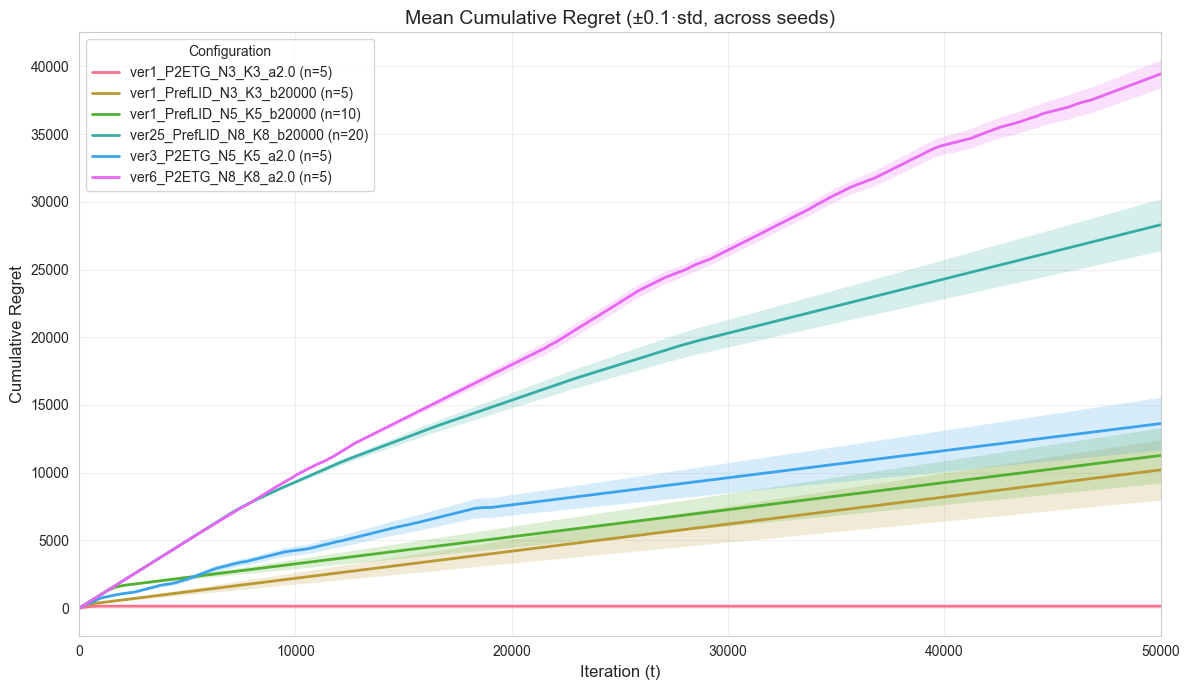

(<Figure size 1200x700 with 1 Axes>,
 <Axes: title={'center': 'Mean Cumulative Regret (±0.1·std, across seeds)'}, xlabel='Iteration (t)', ylabel='Cumulative Regret'>)

In [2]:
LABELS = {
    "N3_K3_a2.0": "N=3, K=3, α=2.0",
    "N5_K5_a2.0": "N=5, K=5, α=2.0",
}

plot_mean_regret_with_std(
    all_data,
    max_iterations=MAX_ITERATIONS,
    show_individual=False,
    labels=LABELS,
        save_path=os.path.join(OUTPUT_DIR, "mean_regret_std.png"),
        std_multiplier=0.1,
)

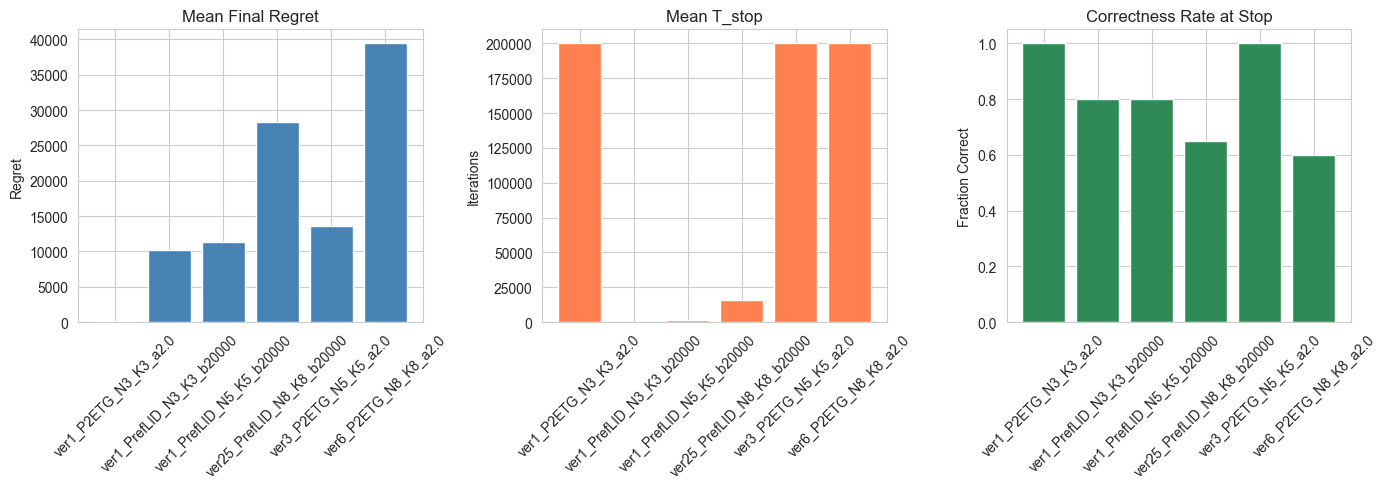

config                  n          T_stop        n_epochs  correct_at_stop    final_regret  stable_under_truth  stable_under_hat  n_stable_matchings      min_bt_gap
--------------------------------------------------------------------------------------------------------------------------------------------------------------------
ver1_P2ETG_N3_K3_a2.0    5  200000.000± 0.000  4000.000± 0.000  1.000± 0.000  150.000±136.931               -               -  1.200± 0.447  0.024± 0.027
ver1_PrefLID_N3_K3_b20000    5               -               -               -  40210.600±89324.999               -               -  1.200± 0.447  0.001± 0.000
ver1_PrefLID_N5_K5_b20000   10               -               -               -  41275.000±83655.819               -               -  1.800± 0.919  0.000± 0.000
ver25_PrefLID_N8_K8_b20000   20               -               -               -  80816.400±90296.813               -               -  2.650± 1.631  0.000± 0.000
ver3_P2ETG_N5_K5_a2.0    5  200000.

In [3]:
# ---- Plot 3: bar summaries ----
plot_summary_stats(all_data)

# ---- Summary.json averages ----
df  = collect_summaries(BASE_DIR)
avg = average_summaries(df, by="config")

print_summary_table(avg, fields=[
    "T_stop", "n_epochs", "correct_at_stop",
    "final_regret", "stable_under_truth", "stable_under_hat",
    "n_stable_matchings", "min_bt_gap",
])